In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pathlib import Path

# -------------------------------------------------------
# PARÁMETROS GLOBALES
# -------------------------------------------------------
MAX_K        = 10  # máximo K a explorar en el codo
RANDOM_STATE = 7    # semilla para reproducibilidad


In [15]:
ruta_csv = '/Users/eliaskablym/Desktop/Computo Paralelo/proyecto computo 1/98000_data_3d.csv'

def cargar_datos(ruta_csv):
    """
    Lee el CSV y devuelve un numpy array.
    Detecta automáticamente si son 2D o 3D según el número de columnas.
    Asume que el CSV no tiene encabezado (solo números).
    """
    datos = pd.read_csv(ruta_csv, header=None)

    n_puntos, n_dims = datos.shape

    # Validamos que sean 2 o 3 dimensiones
    if n_dims not in (2, 3):
        print(f"Error: se esperaban 2 o 3 columnas, pero el CSV tiene {n_dims}.")
        sys.exit(1)

    print(f"\n{'='*50}")
    print(f"  Archivo  : {ruta_csv}")
    print(f"  Puntos   : {n_puntos:,}")
    print(f"  Dimensión: {n_dims}D")
    print(f"{'='*50}\n")

    return datos.values

# --- Probar la función ---
datos = cargar_datos(ruta_csv)


  Archivo  : /Users/eliaskablym/Desktop/Computo Paralelo/proyecto computo 1/98000_data_3d.csv
  Puntos   : 98,000
  Dimensión: 3D



Calculando inercia y silhouette para K = 2 a 10...
(Tarda más que antes por el silhouette)

  K= 1  →  Inercia = 23,209.06  |  Silhouette = N/A
  K= 2  →  Inercia = 9,657.37  |  Silhouette = 0.5717
  K= 3  →  Inercia = 5,053.79  |  Silhouette = 0.6481
  K= 4  →  Inercia = 2,255.38  |  Silhouette = 0.7147
  K= 5  →  Inercia = 970.67  |  Silhouette = 0.7747
  K= 6  →  Inercia = 610.55  |  Silhouette = 0.7081
  K= 7  →  Inercia = 513.16  |  Silhouette = 0.6113
  K= 8  →  Inercia = 520.64  |  Silhouette = 0.5938
  K= 9  →  Inercia = 423.23  |  Silhouette = 0.5003
  K=10  →  Inercia = 409.74  |  Silhouette = 0.4694


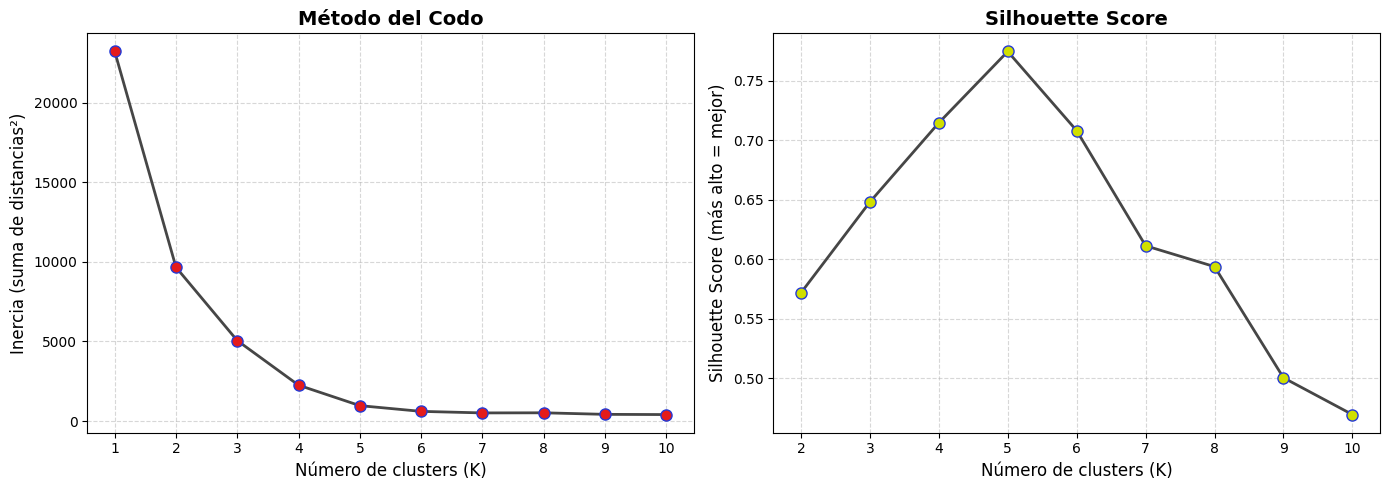


Gráfica guardada como 'grafica_codo_silhouette.png'


In [20]:
%matplotlib inline
from sklearn.metrics import silhouette_score

def metodo_codo(datos, max_k=MAX_K):
    """
    Calcula inercia Y silhouette score para K = 2..max_k.
    - Inercia: buscamos el 'codo' donde deja de bajar mucho
    - Silhouette: buscamos el K con valor más alto (mejor separación)
    Grafica ambas métricas lado a lado.
    """
    print(f"Calculando inercia y silhouette para K = 2 a {max_k}...")
    print("(Tarda más que antes por el silhouette)\n")

    inercias   = []
    silhouettes = []

    # Inercia se puede calcular desde K=1, silhouette necesita mínimo K=2
    km1 = KMeans(n_clusters=1, n_init="auto", random_state=RANDOM_STATE)
    km1.fit(datos)
    inercias.append(km1.inertia_)
    print(f"  K= 1  →  Inercia = {km1.inertia_:,.2f}  |  Silhouette = N/A")

    for k in range(2, max_k + 1):
        km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
        km.fit(datos)
        inercias.append(km.inertia_)

        # Silhouette sobre muestra de 10,000 puntos para que no tarde demasiado
        muestra = min(10000, len(datos))
        idx = np.random.choice(len(datos), muestra, replace=False)
        sil = silhouette_score(datos[idx], km.labels_[idx])
        silhouettes.append(sil)

        print(f"  K={k:2d}  →  Inercia = {km.inertia_:,.2f}  |  Silhouette = {sil:.4f}")

    valores_k     = range(1, max_k + 1)
    valores_k_sil = range(2, max_k + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Gráfica 1: Inercia (codo) ---
    ax1.plot(valores_k, inercias, marker="o", linewidth=2,
             color="#464646", markerfacecolor="#E41B1B",
             markeredgecolor="#2439d6", markersize=8)
    ax1.set_title("Método del Codo", fontsize=14, fontweight="bold")
    ax1.set_xlabel("Número de clusters (K)", fontsize=12)
    ax1.set_ylabel("Inercia (suma de distancias²)", fontsize=12)
    ax1.set_xticks(valores_k)
    ax1.grid(True, linestyle="--", alpha=0.5)

    # --- Gráfica 2: Silhouette ---
    ax2.plot(valores_k_sil, silhouettes, marker="o", linewidth=2,
             color="#464646", markerfacecolor="#d0df00",
             markeredgecolor="#2439d6", markersize=8)
    ax2.set_title("Silhouette Score", fontsize=14, fontweight="bold")
    ax2.set_xlabel("Número de clusters (K)", fontsize=12)
    ax2.set_ylabel("Silhouette Score (más alto = mejor)", fontsize=12)
    ax2.set_xticks(valores_k_sil)
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig("grafica_codo_silhouette.png", dpi=150)
    plt.show()
    plt.close()

    print("\nGráfica guardada como 'grafica_codo_silhouette.png'")
    return inercias, silhouettes


inercias, silhouettes = metodo_codo(datos)